# Anfang
## Daten einlesen

In [1]:
import pandas as pd

path_processed_data = '../Data/Processed/'
time_series = pd.read_csv(path_processed_data + 'cleaned_timeseries.csv')

# Format der Spalte Datum richten
time_series['date'] = pd.to_datetime(time_series['date'])

# Datum in Index bringen
time_series.set_index('date', inplace=True)

# SOnst wissen Modelle später nicht, das Daten auf täglicher Basis
time_series.index.freq = 'D'

print(time_series.head(4))
print()
print(time_series.info())

            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 454 entries, 2013-01-02 to 2014-03-31
Freq: D
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unit_sales  454 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB
None


## Splitten in Trainings- und Testdaten

In [2]:
train_data = time_series.loc["2013-01-01":"2013-12-31"]
test_data  = time_series.loc["2014-01-01":"2014-03-31"]

print(train_data.tail(4))
print()
print(test_data.head(4))

            unit_sales
date                  
2013-12-28       499.0
2013-12-29       552.0
2013-12-30       595.0
2013-12-31       436.0

            unit_sales
date                  
2014-01-01       436.0
2014-01-02       589.0
2014-01-03       474.0
2014-01-04       767.0


# ARIMA
## ADF-Test

In [5]:
from statsmodels.tsa.stattools import adfuller

# adfuller() funktioniert nicht direkt mit Darts TimeSeries –
# wir müssen die Werte extrahieren:
arr = train_data.values.flatten()

result = adfuller(arr)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"ADF p-value: {result[1]:.2e}")
print(f"Critical Values: {result[4]}")

ADF Statistic: -4.2188
ADF p-value: 6.12e-04
Critical Values: {'1%': np.float64(-3.4492815848836296), '5%': np.float64(-2.8698813715275406), '10%': np.float64(-2.5712138845950587)}


- => p-Wert deutlich unter 0.05 => Daten im Sinne der Einheitswurzel stationär

## Pandas Dataframe -> Time.Series Format

In [5]:
from darts import TimeSeries

train_data_ts = TimeSeries.from_dataframe(train_data, value_cols='unit_sales')
test_data_ts = TimeSeries.from_dataframe(test_data, value_cols='unit_sales')

## Model building

In [7]:
# ARIMA aus der Bibliothek darts importieren
from darts.models import ARIMA

# ARIMA-Modell mit (p, d, q) Parametern initialisieren
#arima_model = ARIMA(p=7, d=0, q=1)  # ARIMA(p, d, q)
# !!!! Diese zufällig gewählten Parameter sind deutlich besser als die oben ewig hergeleiteten!!!
arima_model = ARIMA(p=3, d=0, q=3)  # ARIMA(p, d, q)

# ARIMA-Modell mit den Trainingsdaten fitten
arima_model = arima_model.fit(train_data_ts)

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
/opt/miniconda3/envs/work/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximu

## Forecast

In [8]:
# Vorhersage für den Zeitraum der Testdaten (90 Tage = len(test))
arima_forecast = arima_model.predict(len(test_data_ts))

## Plotting

<Axes: xlabel='date'>

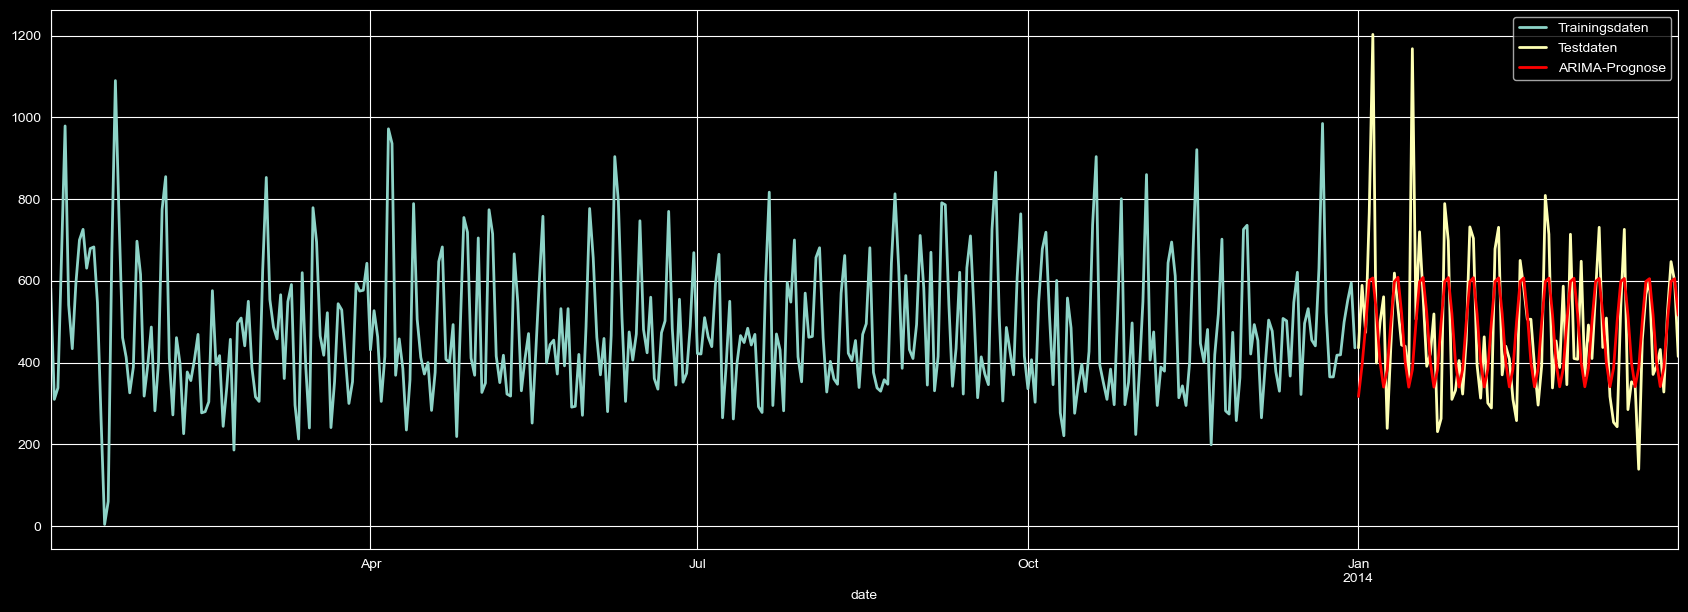

In [9]:
import matplotlib.pyplot as plt

# Prognose (rot) mit tatsächlichen Daten (blau) vergleichen
plt.figure(figsize=(21, 7))  # Größe der Grafik einstellen (Breite, Höhe)
train_data_ts.plot(label='Trainingsdaten')
test_data_ts.plot(label='Testdaten')
arima_forecast.plot(label='ARIMA-Prognose', color='red')

## Evaluierung bis hierher

In [10]:
print(test_data.shape)
print(arima_forecast.shape)

(90, 1)
(90, 1, 1)


=> beides sind 3D-Darts TimeSeries-Objekte und müssen umgewandelt werden in 1D-Array

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# (1) AIC und BIC
aic = arima_model.model.aic
bic = arima_model.model.bic

print(f"ARIMA AIC: {aic:.2f}")
print(f"ARIMA BIC: {bic:.2f}")

# (2) MAE und RMSE
# (2a) Formate anpassen
## .values() => Extrahiert die rohen Zahlen aus dem Darts TimeSeries-Objekt als NumPy-Array – aber in 3D-Form
## .flatten() => Macht daraus ein 1D-Array, das sklearn verarbeiten kann
actual = test_data_ts.values().flatten()
arima_forecast_arr = arima_forecast.values().flatten()

mae = mean_absolute_error(actual, arima_forecast_arr)
rmse = np.sqrt(mean_squared_error(actual, arima_forecast_arr))

print(f"ARIMA MAE: {mae:.2f}")
print(f"ARIMA RMSE: {rmse:.2f}")

ARIMA AIC: 4610.83
ARIMA BIC: 4642.00
ARIMA MAE: 114.74
ARIMA RMSE: 159.38


## Hyperopt (Hyperparameter Optimization)
### Install required packages

In [12]:
import numpy as np
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

### Define the hyperparameter search space

In [13]:
# Define the hyperparameter search space
space = {
    'p': hp.quniform('p', 1, 30, 1),
    'q': hp.quniform('q', 1, 30, 1),
    'd': hp.quniform('d', 0, 3, 1)
}

### Define Objective Function

In [14]:
def objective(params):
    params = {
        'p': int(params['p']),
        'q': int(params['q']),
        'd': int(params['d']),
    }

    model = ARIMA(**params)
    model.fit(train_data_ts)                          # ← fit nötig!
    forecast = model.predict(len(test_data_ts))       # ← lokale Variable
    predicted = forecast.values().flatten()
    actual = test_data_ts.values().flatten()          # ← auch lokal definieren

    errors = actual - predicted
    smape = np.mean(2 * np.abs(errors) / (np.abs(actual) + np.abs(predicted)))
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(actual)
    mape  = np.mean(np.abs(errors) / np.abs(actual)) * 100
    bias  = np.mean(errors)

    return {
        'loss':   smape,
        'status': STATUS_OK,
        'rmse':   rmse,
        'mad':    mad,
        'rmad':   rmad,
        'mape':   mape,
        'bias':   bias,
    }

In [13]:
"""
p: 1–30 → 30 Werte
q: 1–30 → 30 Werte
d: 0–3 → 4 Werte

=> 30 × 30 × 4 = 3.600 Kombinationen
"""

'\np: 1–30 → 30 Werte\nq: 1–30 → 30 Werte\nd: 0–3 → 4 Werte\n\n=> 30 × 30 × 4 = 3.600 Kombinationen\n'

### Run Optimization

In [16]:
# Initialize trials object to track progress
trials = Trials()

# Run optimization
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials
)

print("\nBest parameters found:")
print(best)

# Alle Metriken als DataFrame
results_ARIMA = pd.DataFrame(trials.results)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'



  2%|▏         | 1/50 [00:05<04:36,  5.65s/trial, best loss: 0.26633441448378825]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  4%|▍         | 2/50 [00:24<10:47, 13.50s/trial, best loss: 0.26633441448378825]

...

 96%|█████████▌| 48/50 [08:38<00:28, 14.03s/trial, best loss: 0.21087334439056482]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



 98%|█████████▊| 49/50 [08:42<00:10, 10.85s/trial, best loss: 0.21087334439056482]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



100%|██████████| 50/50 [09:10<00:00, 11.01s/trial, best loss: 0.21087334439056482]

Best parameters found:
{'d': np.float64(0.0), 'p': np.float64(21.0), 'q': np.float64(30.0)}


In [15]:
results_ARIMA.sort_values('loss').head(1)

,loss,status,rmse,mad,rmad,mape,bias
0,0.242756,ok,159.380713,114.735333,0.236432,26.833825,6.243747


## Finales Modell mit besten Hyperparametern
### Beste Hyperparameter extrahieren

In [19]:
# Besten Trial finden
best_trial_ARIMA = trials.best_trial['misc']['vals']

# Parameter extrahieren
best_params_ARIMA = {
    'p': int(best_trial_ARIMA['p'][0]),
    'q': int(best_trial_ARIMA['q'][0]),
    'd': int(best_trial_ARIMA['d'][0]),
}

print(best_params_ARIMA)

{'p': 21, 'q': 30, 'd': 0}


### Trainieren

In [20]:
# Finales ARIMA-Modell mit besten Hyperparametern trainieren
final_model_ARIMA = ARIMA(**best_params_ARIMA)
final_model_ARIMA.fit(train_data_ts)

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(p=21, d=0, q=30, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

### Forecast

In [21]:
# Forecast für den Testzeitraum (90 Tage)
arima_forecast_final = final_model_ARIMA.predict(len(test_data_ts))

### Evaluation

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

def forecast_metrics(y_true, y_pred):
    errors = y_true - y_pred
    smape = np.mean(2 * np.abs(errors) / (np.abs(y_true) + np.abs(y_pred)))
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_true)
    mape  = np.mean(np.abs(errors) / np.abs(y_true)) * 100
    bias  = np.mean(errors)

    return {
        'SMAPE': smape,
        'RMSE':  rmse,
        'MAD':   mad,
        'rMAD':  rmad,
        'MAPE':  mape,
        'Bias':  bias,
    }

# Evaluation
actual = test_data_ts.values().flatten()
predicted_ARIMA = arima_forecast_final.values().flatten()

metrics_ARIMA = forecast_metrics(actual, predicted_ARIMA)
for k, v in metrics_ARIMA.items():
    print(f"{k}: {v:,.2f}")

SMAPE: 0.21
RMSE: 142.09
MAD: 98.68
rMAD: 0.20
MAPE: 22.86
Bias: 4.65


### Plotting

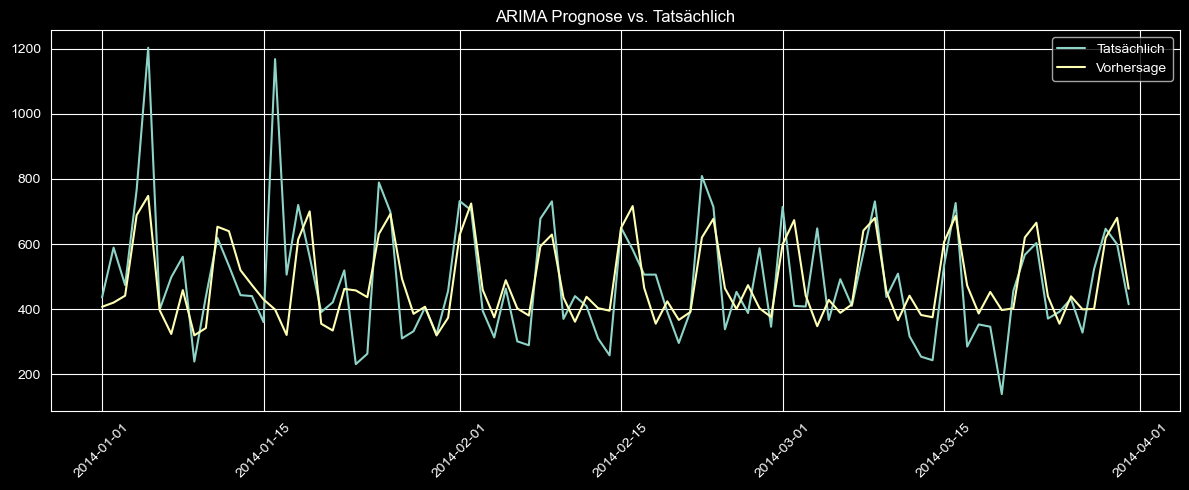

In [25]:
# Forecast-Plot mit fig-Objekt erstellen (nötig für mlflow.log_figure)
test_dates_ARIMA = pd.date_range(start='2014-01-01', periods=len(test_data_ts), freq='D')

fig_ARIMA, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates_ARIMA, actual, label='Tatsächlich')
ax.plot(test_dates_ARIMA, predicted_ARIMA, label='Vorhersage')
ax.legend()
ax.set_title('ARIMA Prognose vs. Tatsächlich')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ML Flow
### Starten

In [27]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db")
mlflow.set_experiment("sales_forecast")

# Jetzt wichtig: mlflow ui mit der DB starten. Im Terminal:
# mlflow ui --backend-store-uri sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db

<Experiment: artifact_location='/Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/Scripts/mlruns/1', creation_time=1777470068881, experiment_id='1', last_update_time=1777470068881, lifecycle_stage='active', name='sales_forecast', tags={}, trace_location=None, workspace='default'>

### Logging

In [28]:
with mlflow.start_run(run_name="ARIMA"):

    # Qualitative Zusatzinfos
    mlflow.set_tag("forecasting_method", "iterative")
    mlflow.set_tag("model_type", "statistical")

    # Beste Hyperparameter loggen
    mlflow.log_params(best_params_ARIMA)

    # Train/Test-Split Info loggen
    mlflow.log_param("train_size", len(train_data_ts))
    mlflow.log_param("test_size", len(test_data_ts))
    mlflow.log_param("test_start", "2014-01-01")
    mlflow.log_param("test_end", "2014-03-31")

    # Evaluationsmetriken loggen (bereits berechnet)
    mlflow.log_metric("SMAPE", metrics_ARIMA["SMAPE"])
    mlflow.log_metric("RMSE",  metrics_ARIMA["RMSE"])
    mlflow.log_metric("MAD",   metrics_ARIMA["MAD"])
    mlflow.log_metric("rMAD",  metrics_ARIMA["rMAD"])
    mlflow.log_metric("MAPE",  metrics_ARIMA["MAPE"])
    mlflow.log_metric("Bias",  metrics_ARIMA["Bias"])

    # Forecast-Plot als Artefakt speichern
    mlflow.log_figure(fig_ARIMA, "forecast_plot.png")

    # Modell als Artefakt speichern (darts hat kein natives mlflow flavor)
    # → Modell wird als Datei gespeichert und als Artefakt geloggt
    final_model_ARIMA.save("/tmp/arima_model")
    mlflow.log_artifact("/tmp/arima_model")

# SARIMA
## Model building

In [29]:
from darts.models import ARIMA

# Initialize ARIMA model with both (p, d, q) and (P, D, Q, m) parameters
sarima_model = ARIMA(p=3, d=0, q=3, seasonal_order=(1, 1, 1, 7))

# Fit the ARIMA model with seasonality on the training data
sarima_model.fit(train_data_ts)

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(p=3, d=0, q=3, seasonal_order=(1, 1, 1, 7), trend=None, random_state=None, add_encoders=None)

## Forecast

In [30]:
# Forecast the next values (the same length as the test set)
sarima_forecast = sarima_model.predict(len(test_data_ts))

## Plotting

<Axes: xlabel='date'>

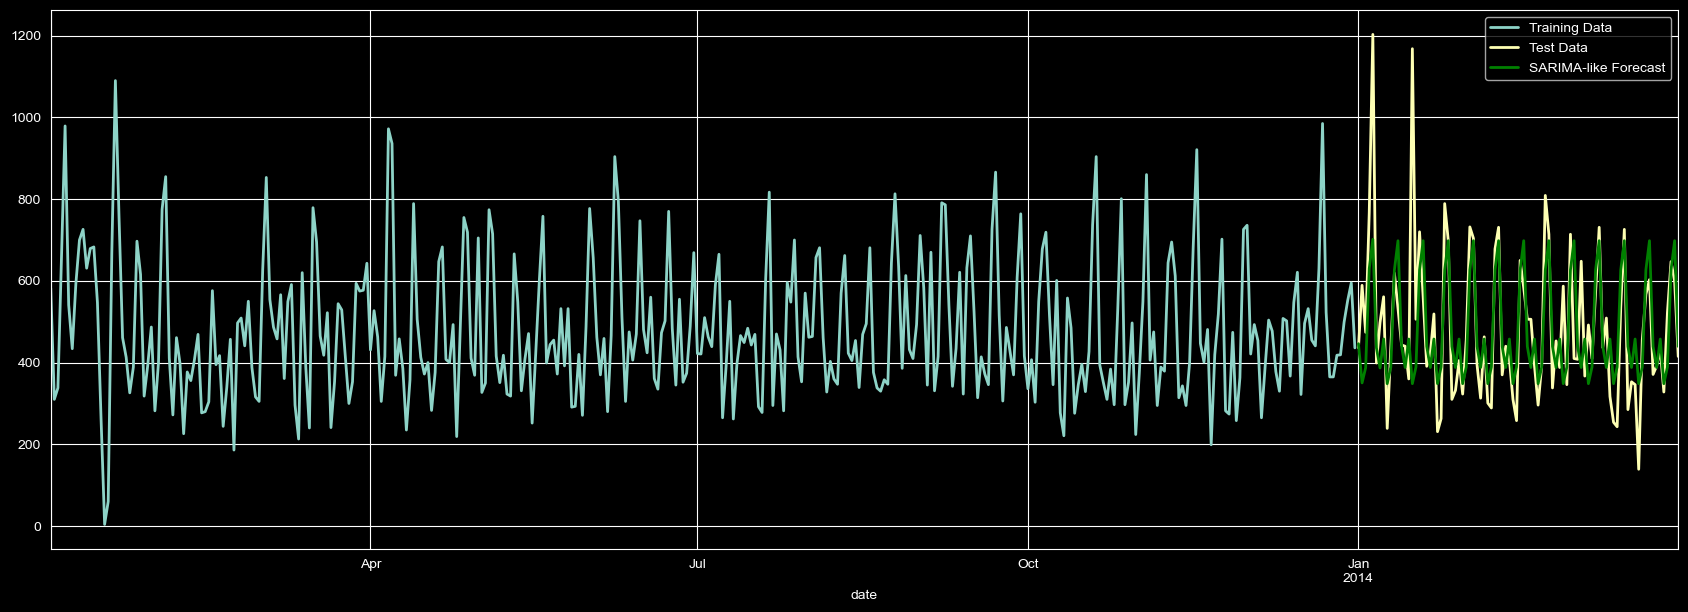

In [31]:
# Plot SARIMA-like forecast vs actual data
plt.figure(figsize=(21, 7))  # Adjust the figure size (width, height)
train_data_ts.plot(label='Training Data')
test_data_ts.plot(label='Test Data')
sarima_forecast.plot(label='SARIMA-like Forecast', color='green')

## Evaluation bis hierher

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# (1) AIC und BIC
aic = sarima_model.model.aic
bic = sarima_model.model.bic

print(f"SARIMA AIC: {aic:.2f}")
print(f"SARIMA BIC: {bic:.2f}")

# (2) MAE und RMSE
# (2a) Formate anpassen
## .values() => Extrahiert die rohen Zahlen aus dem Darts TimeSeries-Objekt als NumPy-Array – aber in 3D-Form
## .flatten() => Macht daraus ein 1D-Array, das sklearn verarbeiten kann
actual = test_data_ts.values().flatten()
sarima_forecast_arr = sarima_forecast.values().flatten()

mae = mean_absolute_error(actual, sarima_forecast_arr)
rmse = np.sqrt(mean_squared_error(actual, sarima_forecast_arr))

print(f"SARIMA MAE: {mae:.2f}")
print(f"SARIMA RMSE: {rmse:.2f}")

SARIMA AIC: 4418.00
SARIMA BIC: 4452.90
SARIMA MAE: 94.29
SARIMA RMSE: 142.63


## Hyperopt (Hyperparameter Optimization)
### Define the hyperparameter search space

In [41]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np
from sklearn.metrics import mean_squared_error

# s ist fix auf 7 (Wochensaisonalität aus EDA bekannt → nicht optimieren)
SARIMA_S = 7

# Search Space: nur p, q, d, P, D, Q werden optimiert
space = {
    'p': hp.quniform('p', 1, 6, 1),   # AR-Lags: muss < s=7 bleiben
    'q': hp.quniform('q', 0, 3, 1),   # MA-Lags
    'd': hp.quniform('d', 0, 1, 1),   # Differenzierung
    'P': hp.quniform('P', 0, 2, 1),   # saisonale AR-Lags; P=1 → y_{t-7} → vor 7 Tagen (gleicher Wochentag letzte Woche)
    'D': hp.quniform('D', 0, 1, 1),   # saisonale Differenzierung
    'Q': hp.quniform('Q', 0, 2, 1),   # saisonale MA-Lags
}

### Define Objective Function

In [42]:
def objective(params):
    params = {
        'p': int(params['p']),
        'q': int(params['q']),
        'd': int(params['d']),
        'P': int(params['P']),
        'D': int(params['D']),
        'Q': int(params['Q']),
    }

    # Modell initialisieren und trainieren
    model = ARIMA(
        p=params['p'],
        d=params['d'],
        q=params['q'],
        seasonal_order=(params['P'], params['D'], params['Q'], SARIMA_S)
    )
    model.fit(train_data_ts)

    # Forecast und Metriken berechnen
    forecast = model.predict(len(test_data_ts))
    predicted = forecast.values().flatten()
    actual = test_data_ts.values().flatten()
    errors = actual - predicted

    smape = np.mean(2 * np.abs(errors) / (np.abs(actual) + np.abs(predicted)))
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(actual)
    mape  = np.mean(np.abs(errors) / np.abs(actual)) * 100
    bias  = np.mean(errors)

    return {
        'loss':   smape,      # Hyperopt minimiert diesen Wert
        'status': STATUS_OK,
        'rmse':   rmse,
        'mad':    mad,
        'rmad':   rmad,
        'mape':   mape,
        'bias':   bias,
    }

### Run Optimization

In [44]:
# Hyperopt ausführen
trials_SARIMA = Trials()

best_SARIMA = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,         # begrenzt auf 20 wegen hoher Rechenzeit (~30s pro Trial)
    trials=trials_SARIMA
)

print("\nBest parameters found:")
print(best_SARIMA)

# Alle Metriken als DataFrame
results_SARIMA = pd.DataFrame(trials_SARIMA.results)

  4%|▍         | 2/50 [00:04<01:49,  2.29s/trial, best loss: 0.20030137449282487]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



  6%|▌         | 3/50 [00:06<01:41,  2.15s/trial, best loss: 0.20030137449282487]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  8%|▊         | 4/50 [00:06<01:13,  1.60s/trial, best loss: 0.20030137449282487]

...

 90%|█████████ | 45/50 [00:55<00:07,  1.56s/trial, best loss: 0.19934380056363069]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



 96%|█████████▌| 48/50 [00:59<00:02,  1.37s/trial, best loss: 0.19934380056363069]

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



100%|██████████| 50/50 [01:01<00:00,  1.22s/trial, best loss: 0.19934380056363069]

Best parameters found:
{'D': np.float64(1.0), 'P': np.float64(1.0), 'Q': np.float64(1.0), 'd': np.float64(0.0), 'p': np.float64(1.0), 'q': np.float64(3.0)}


In [45]:
results_SARIMA.sort_values('loss').head(1)

,loss,status,rmse,mad,rmad,mape,bias
9,0.199344,ok,142.470104,94.197899,0.194111,21.013772,6.041459


## Finales Modell mit besten Hyperparametern
### Beste Hyperparameter extrahieren

In [46]:
# Besten Trial finden
best_trial_SARIMA = trials_SARIMA.best_trial['misc']['vals']

# Parameter extrahieren (alle int da p, d, q, P, D, Q ganzzahlig)
best_params_SARIMA = {
    'p': int(best_trial_SARIMA['p'][0]),
    'q': int(best_trial_SARIMA['q'][0]),
    'd': int(best_trial_SARIMA['d'][0]),
    'P': int(best_trial_SARIMA['P'][0]),
    'D': int(best_trial_SARIMA['D'][0]),
    'Q': int(best_trial_SARIMA['Q'][0]),
}

print(best_params_SARIMA)
print(f"Saisonale Periode: s={SARIMA_S} (fix)")

{'p': 1, 'q': 3, 'd': 0, 'P': 1, 'D': 1, 'Q': 1}
Saisonale Periode: s=7 (fix)


### Trainieren

In [47]:
# Finales SARIMA-Modell mit besten Hyperparametern trainieren
final_model_SARIMA = ARIMA(
    p=best_params_SARIMA['p'],
    d=best_params_SARIMA['d'],
    q=best_params_SARIMA['q'],
    seasonal_order=(
        best_params_SARIMA['P'],
        best_params_SARIMA['D'],
        best_params_SARIMA['Q'],
        SARIMA_S
    )
)
final_model_SARIMA.fit(train_data_ts)

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(p=1, d=0, q=3, seasonal_order=(1, 1, 1, 7), trend=None, random_state=None, add_encoders=None)

### Forecast

In [48]:
# Forecast für den Testzeitraum (90 Tage, iteratives Forecasting)
sarima_forecast_final = final_model_SARIMA.predict(len(test_data_ts))

### Evaluation

In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

def forecast_metrics(y_true, y_pred):
    errors = y_true - y_pred
    smape = np.mean(2 * np.abs(errors) / (np.abs(y_true) + np.abs(y_pred)))
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_true)
    mape  = np.mean(np.abs(errors) / np.abs(y_true)) * 100
    bias  = np.mean(errors)

    return {
        'SMAPE': smape,
        'RMSE':  rmse,
        'MAD':   mad,
        'rMAD':  rmad,
        'MAPE':  mape,
        'Bias':  bias,
    }

# Evaluation
actual = test_data_ts.values().flatten()
predicted_SARIMA = sarima_forecast_final.values().flatten()

metrics_SARIMA = forecast_metrics(actual, predicted_SARIMA)
for k, v in metrics_SARIMA.items():
    print(f"{k}: {v:,.2f}")

SMAPE: 0.20
RMSE: 142.47
MAD: 94.20
rMAD: 0.19
MAPE: 21.01
Bias: 6.04


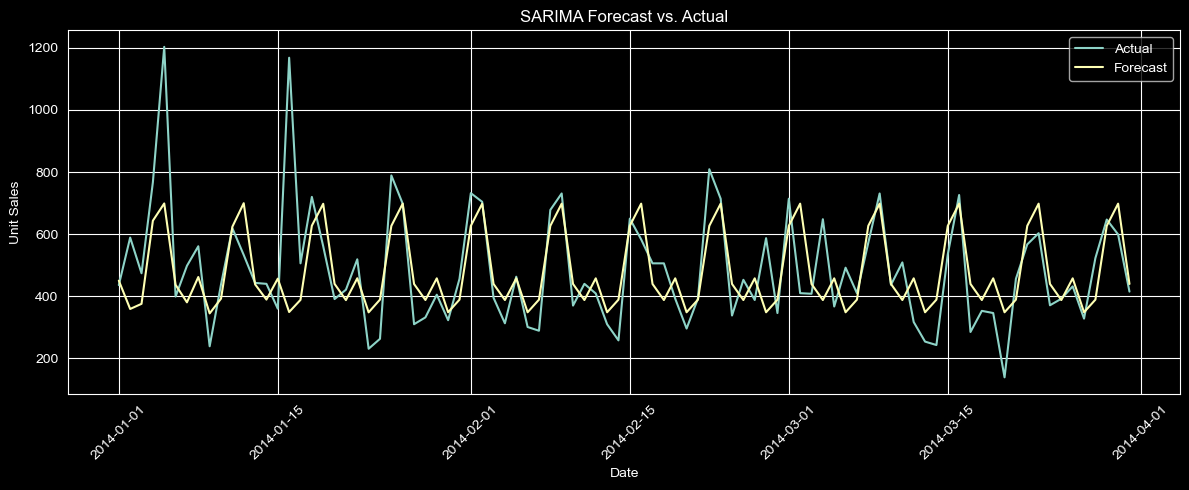

In [50]:
# Forecast-Plot mit fig-Objekt erstellen (nötig für mlflow.log_figure)
test_dates_SARIMA = pd.date_range(start='2014-01-01', periods=len(test_data_ts), freq='D')

fig_SARIMA, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates_SARIMA, actual, label='Actual')
ax.plot(test_dates_SARIMA, predicted_SARIMA, label='Forecast')
ax.legend()
ax.set_title('SARIMA Forecast vs. Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Unit Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ML Flow
### Starten

In [ ]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db")
mlflow.set_experiment("sales_forecast")

# Jetzt wichtig: mlflow ui mit der DB starten. Im Terminal:
# mlflow ui --backend-store-uri sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db

### Logging


In [51]:
with mlflow.start_run(run_name="SARIMA"):

    # Qualitative Zusatzinfos
    mlflow.set_tag("forecasting_method", "iterative")
    mlflow.set_tag("model_type", "statistical")

    # Beste Hyperparameter loggen
    mlflow.log_params(best_params_SARIMA)
    mlflow.log_param("s", SARIMA_S)  # s ist fix, aber trotzdem dokumentieren

    # Train/Test-Split Info loggen
    mlflow.log_param("train_size", len(train_data_ts))
    mlflow.log_param("test_size", len(test_data_ts))
    mlflow.log_param("test_start", "2014-01-01")
    mlflow.log_param("test_end", "2014-03-31")

    # Evaluationsmetriken loggen
    mlflow.log_metric("SMAPE", metrics_SARIMA["SMAPE"])
    mlflow.log_metric("RMSE",  metrics_SARIMA["RMSE"])
    mlflow.log_metric("MAD",   metrics_SARIMA["MAD"])
    mlflow.log_metric("rMAD",  metrics_SARIMA["rMAD"])
    mlflow.log_metric("MAPE",  metrics_SARIMA["MAPE"])
    mlflow.log_metric("Bias",  metrics_SARIMA["Bias"])

    # Forecast-Plot als Artefakt speichern
    mlflow.log_figure(fig_SARIMA, "forecast_plot.png")

    # Modell als Artefakt speichern (darts hat kein natives mlflow flavor)
    final_model_SARIMA.save("/tmp/sarima_model")
    mlflow.log_artifact("/tmp/sarima_model")

# Single, Double and Triple Exponential Smoothing (ES)
## Fit models and generate forecasts

In [52]:
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
import matplotlib.pyplot as plt

forecast_horizon = 90  # Forecast next 12 points

# Simple Exponential Smoothing
#simple_model = SimpleExpSmoothing(train_data).fit()
simple_model = SimpleExpSmoothing(train_data['unit_sales']).fit()
simple_fitted = simple_model.fittedvalues
simple_forecast = simple_model.forecast(forecast_horizon)

# Double Exponential Smoothing (Holt)
#double_model = Holt(train_data).fit()
double_model = Holt(train_data['unit_sales']).fit()
double_fitted = double_model.fittedvalues
double_forecast = double_model.forecast(forecast_horizon)

# Triple Exponential Smoothing (Holt-Winters)
#triple_model = ExponentialSmoothing(train_data, seasonal_periods=12, trend='add', seasonal='add').fit()
triple_model = ExponentialSmoothing(
    train_data['unit_sales'],
    seasonal_periods=7,
    trend='add',    # -> additives Model
    seasonal='add'  # -> additives Model
).fit()

triple_fitted = triple_model.fittedvalues
triple_forecast = triple_model.forecast(forecast_horizon)

In [53]:
simple_forecast.head(4)

2014-01-01    480.765552
2014-01-02    480.765552
2014-01-03    480.765552
2014-01-04    480.765552
Freq: D, dtype: float64

## Plotting

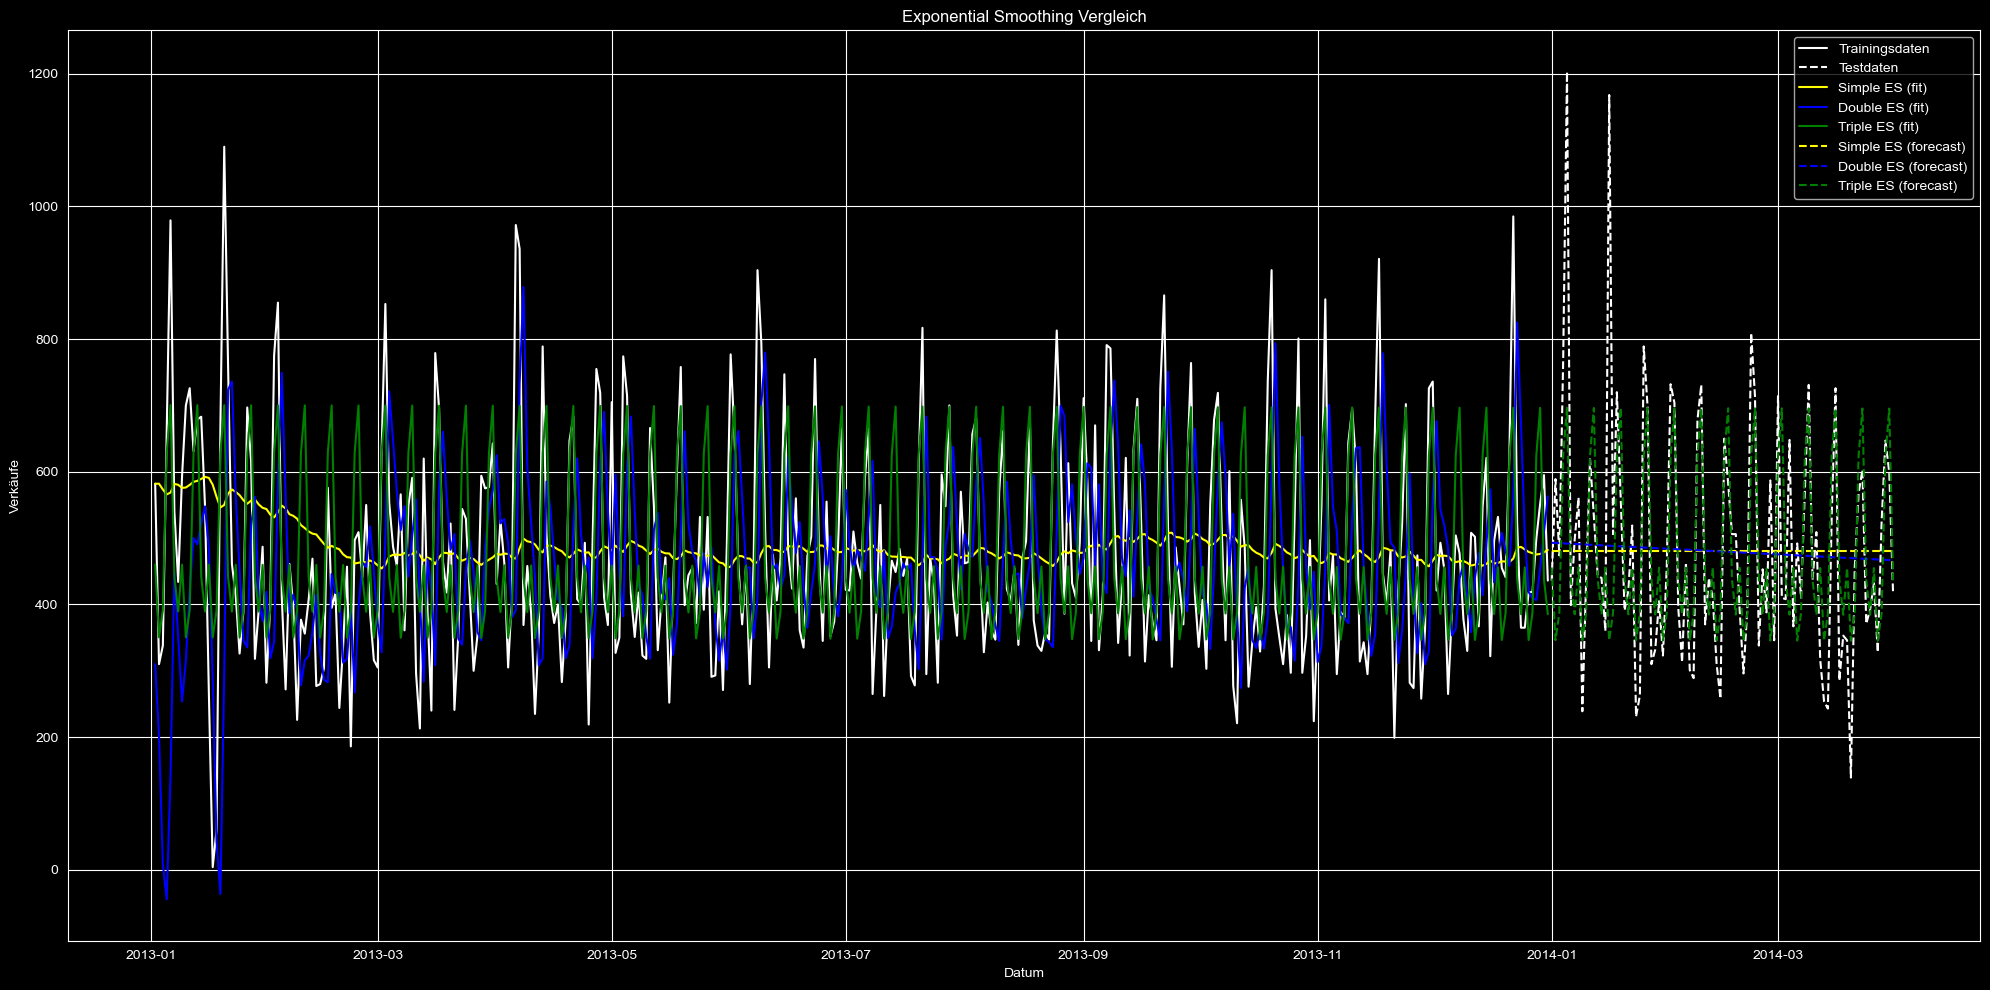

In [54]:
plt.figure(figsize=(20, 10))

# Trainingsdaten
plt.plot(train_data.index, train_data, label='Trainingsdaten', color='white')

# Testdaten
plt.plot(test_data.index, test_data, label='Testdaten', color='white', linestyle='--')

# Gefittete Werte (auf Trainingsdaten)
plt.plot(train_data.index, simple_fitted, label='Simple ES (fit)', color='yellow', linestyle='-')
plt.plot(train_data.index, double_fitted, label='Double ES (fit)', color='blue', linestyle='-')
plt.plot(train_data.index, triple_fitted, label='Triple ES (fit)', color='green', linestyle='-')

# Forecasts (auf Testzeitraum)
plt.plot(simple_forecast.index, simple_forecast, label='Simple ES (forecast)', color='yellow', linestyle='--')
plt.plot(double_forecast.index, double_forecast, label='Double ES (forecast)', color='blue', linestyle='--')
plt.plot(triple_forecast.index, triple_forecast, label='Triple ES (forecast)', color='green', linestyle='--')

plt.legend()
plt.title('Exponential Smoothing Vergleich')
plt.xlabel('Datum')
plt.ylabel('Verkäufe')
plt.tight_layout()
plt.show()

## Evaluierung bis hierhin

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Forecast-Werte auf Testzeitraum zuschneiden
simple_pred = simple_forecast[:len(test_data)]
double_pred = double_forecast[:len(test_data)]
triple_pred = triple_forecast[:len(test_data)]

actual = test_data['unit_sales'].values

# MAE
print(f"Simple ES  MAE: {mean_absolute_error(actual, simple_pred):.2f}")
print(f"Double ES  MAE: {mean_absolute_error(actual, double_pred):.2f}")
print(f"Triple ES  MAE: {mean_absolute_error(actual, triple_pred):.2f}")
print()

# RMSE
print(f"Simple ES  RMSE: {np.sqrt(mean_squared_error(actual, simple_pred)):.2f}")
print(f"Double ES  RMSE: {np.sqrt(mean_squared_error(actual, double_pred)):.2f}")
print(f"Triple ES  RMSE: {np.sqrt(mean_squared_error(actual, triple_pred)):.2f}")
print()

# AIC
print(f"Simple ES  AIC: {simple_model.aic:.1f}")
print(f"Double ES  AIC: {double_model.aic:.1f}")
print(f"Triple ES  AIC: {triple_model.aic:.1f}")
print()

# BIC
print(f"Simple ES  BIC: {simple_model.bic:.1f}")
print(f"Double ES  BIC: {double_model.bic:.1f}")
print(f"Triple ES  BIC: {triple_model.bic:.1f}")

Simple ES  MAE: 140.55
Double ES  MAE: 139.95
Triple ES  MAE: 94.37

Simple ES  RMSE: 183.53
Double ES  RMSE: 182.33
Triple ES  RMSE: 142.95

Simple ES  AIC: 3741.7
Double ES  AIC: 3893.6
Triple ES  AIC: 3464.6

Simple ES  BIC: 3749.5
Double ES  BIC: 3909.2
Triple ES  BIC: 3507.5


## Interpretation bis hierhin

- Triple ES gewinnt klar – konsistent bestes Ergebnis auf allen Metriken.
- Auffällig: Double ES ist schlechter als Simple ES. Das macht intuitiv Sinn: Die Daten haben keinen Trend – Double ES modelliert aber einen.
- RMSE deutlich größer als MAE → das Modell hat einige größere Ausreißerfehler. Im Schnitt liegt es 98 daneben, aber einzelne Tage weicht es stärker ab
-
- INTERESSANT:
- SARIMA erfordert ewiges herumgeschraube an Parametern, während Triple ES einfach läuft
- hatte MAE = 97.65 – also praktisch identisch mit Triple ES (98.43). Triple ES erreicht also mit viel weniger Aufwand dasselbe Ergebnis
- SARIMA vs Triple exponential Smoothing:
    - Triple ES → einfacher, schneller, robuster als SARMIA
    - SARIMA → flexibler, interpretierbarer, kann komplexere Autokorrelationsstrukturen abbilden
    - => In der Praxis gilt oft: Triple ES als starke Baseline, SARIMA wenn man mehr Kontrolle oder bessere Ergebnisse braucht.

## Hyperopt (Hyperparameter Optimization)
### Define the hyperparameter search space

In [56]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Define the hyperparameter search space
space = {
    'trend':    hp.choice('trend',    ['add', 'mul', None]),            # additiver/multiplikativer Trend oder keiner
    'seasonal': hp.choice('seasonal', ['add', 'mul', None]),            # additiv/multiplikativ oder keine Saisonalität
    'seasonal_periods': hp.choice('seasonal_periods', [7, 30]),         # Länge eines Zyklus (7=wöchentlich, 30=monatlich)
    'damped_trend': hp.choice('damped_trend', [True, False]),           # Trend flacht langfristig ab → oft realistischer
    'use_boxcox': hp.choice('use_boxcox', [True, False]),               # Transformation für nicht-normale Daten
}

"""
Wie viele Kombinationen sind möglich:

trend: 3 (add, mul, None)
seasonal: 2 (add, mul)
seasonal_periods: 2 (7, 30)
damped_trend: 2 (True, False)
use_boxcox: 2 (True, False)

→ 3 × 2 × 2 × 2 × 2 = 48

"""

'\nWie viele Kombinationen sind möglich:\n\ntrend: 3 (add, mul, None)\nseasonal: 2 (add, mul)\nseasonal_periods: 2 (7, 30)\ndamped_trend: 2 (True, False)\nuse_boxcox: 2 (True, False)\n\n→ 3 × 2 × 2 × 2 × 2 = 48\n\n'

### Define Objective Function

In [57]:
def objective(params):

    # (1) damped_trend=True ist nur erlaubt wenn trend nicht None ist
    trend = params['trend']
    damped_trend = params['damped_trend']
    if trend is None:
        damped_trend = False

    # (2) Modell trainieren
    model = ExponentialSmoothing(
        train_data['unit_sales'],
        trend=trend,
        seasonal=params['seasonal'],
        seasonal_periods=int(params['seasonal_periods']),
        damped_trend=damped_trend,
        use_boxcox=params['use_boxcox'],
    ).fit()

    # (3) Forecast und Metriken
    actual = test_data['unit_sales'].values      # ← lokal definieren
    predicted = model.forecast(len(actual))
    errors = actual - predicted

    smape = np.mean(2 * np.abs(errors) / (np.abs(actual) + np.abs(predicted)))
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(actual)
    mape  = np.mean(np.abs(errors) / np.abs(actual)) * 100
    bias  = np.mean(errors)

    return {
        'loss':   smape,
        'status': STATUS_OK,
        'rmse':   rmse,
        'mad':    mad,
        'rmad':   rmad,
        'mape':   mape,
        'bias':   bias,
    }

### Run Optimization

In [58]:
# Initialize trials object to track progress
trials_ES = Trials()

# Run optimization
best_ES = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=48,        # vollständige Grid Search bei 48 Kombinationen
    trials=trials_ES
)

print("\nBest parameters found:")
print(best_ES)

# Alle Metriken als DataFrame
results_ES = pd.DataFrame(trials_ES.results)

100%|██████████| 48/48 [00:06<00:00,  7.37trial/s, best loss: 0.1977763853059738] 

Best parameters found:
{'damped_trend': np.int64(0), 'seasonal': np.int64(0), 'seasonal_periods': np.int64(0), 'trend': np.int64(0), 'use_boxcox': np.int64(0)}


In [59]:
# Bestes Trial heraussuchen
best_trial = min(trials.results, key=lambda x: x['loss'])
print(best_trial)

{'loss': 0.21087334439056482, 'status': 'ok', 'rmse': np.float64(142.08735680276845), 'mad': np.float64(98.67930999371781), 'rmad': np.float64(0.2033460308971861), 'mape': np.float64(22.857145602818434), 'bias': np.float64(4.649384582108892)}


In [60]:
results_ES.sort_values('loss').head(1)

,loss,status,rmse,mad,rmad,mape,bias
38,0.197776,ok,143.643361,93.864542,0.193424,20.374321,14.972507


### KURZER EINSCHUB Theorie

Wichtiger Hinweis: Hyperopt speichert keine Modelle

`results_ES.sort_values('loss').head(1)` zeigt den besten Trial:
- beste Parameter
- niedrigster SMAPE auf dem Testset

Aber das Modell-Objekt selbst wird von Hyperopt **nicht gespeichert** – nur die Metriken.

=> Finales Modell muss mit den besten Parametern **nochmal trainiert** werden.

**Warum?**
MLflow speichert nicht nur Metriken und Parameter, sondern auch das trainierte
Modell-Objekt als Artefakt ("model"). Dieses Artefakt wird später in Streamlit
geladen via `mlflow.load_model()` – ohne nochmaliges Training.
Dafür braucht MLflow das Modell-Objekt, das Hyperopt nicht aufbewahrt hat.

Ablauf für jedes Modell:
1. Beste Parameter extrahieren aus `trials.best_trial`
2. Modell nochmal trainieren mit diesen Parametern  ← MLflow braucht dieses Objekt
3. Forecast auf Testset
4. Evaluation + Plot
5. MLflow Logging (Parameter, Metriken, Modell-Artefakt)

## Finales Modell mit besten Hyperparametern
### Beste Hyperparameter extrahieren

In [63]:
# Besten Trial finden
best_trial_ES = trials_ES.best_trial['misc']['vals']

# Parameter extrahieren (hp.choice → Index zurückgeben → Wert mappen)
best_params_ES = {
    'trend':            ['add', 'mul', None][int(best_trial_ES['trend'][0])],
    'seasonal':         ['add', 'mul', None][int(best_trial_ES['seasonal'][0])],
    'seasonal_periods': [7, 30][int(best_trial_ES['seasonal_periods'][0])],
    'damped_trend':     [True, False][int(best_trial_ES['damped_trend'][0])],
    'use_boxcox':       [True, False][int(best_trial_ES['use_boxcox'][0])],
}

print(best_params_ES)

{'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 7, 'damped_trend': True, 'use_boxcox': True}


### Trainieren

In [65]:
# damped_trend nur erlaubt wenn trend nicht None
trend = best_params_ES['trend']
damped_trend = best_params_ES['damped_trend']
if trend is None:
    damped_trend = False

# Finales ES-Modell mit besten Parametern trainieren
final_model_ES = ExponentialSmoothing(
    train_data['unit_sales'],
    trend=trend,
    seasonal=best_params_ES['seasonal'],
    seasonal_periods=best_params_ES['seasonal_periods'],
    damped_trend=damped_trend,
    use_boxcox=best_params_ES['use_boxcox'],
).fit()

### Forecast

In [66]:
# Forecast für den Testzeitraum (90 Tage, iteratives Forecasting)
es_forecast_final = final_model_ES.forecast(len(test_data))

### Evaluation

In [67]:
from sklearn.metrics import mean_squared_error
import numpy as np

def forecast_metrics(y_true, y_pred):
    errors = y_true - y_pred
    smape = np.mean(2 * np.abs(errors) / (np.abs(y_true) + np.abs(y_pred)))
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_true)
    mape  = np.mean(np.abs(errors) / np.abs(y_true)) * 100
    bias  = np.mean(errors)

    return {
        'SMAPE': smape,
        'RMSE':  rmse,
        'MAD':   mad,
        'rMAD':  rmad,
        'MAPE':  mape,
        'Bias':  bias,
    }

# Actual und Predicted als numpy arrays
actual_ES    = test_data['unit_sales'].values      # echte Werte aus Test-DataFrame
predicted_ES = es_forecast_final.values            # Forecast aus finalem ES-Modell

# Metriken berechnen
metrics_ES = forecast_metrics(actual_ES, predicted_ES)
for k, v in metrics_ES.items():
    print(f"{k}: {v:,.2f}")

SMAPE: 0.20
RMSE: 143.64
MAD: 93.86
rMAD: 0.19
MAPE: 20.37
Bias: 14.97


### Plotting

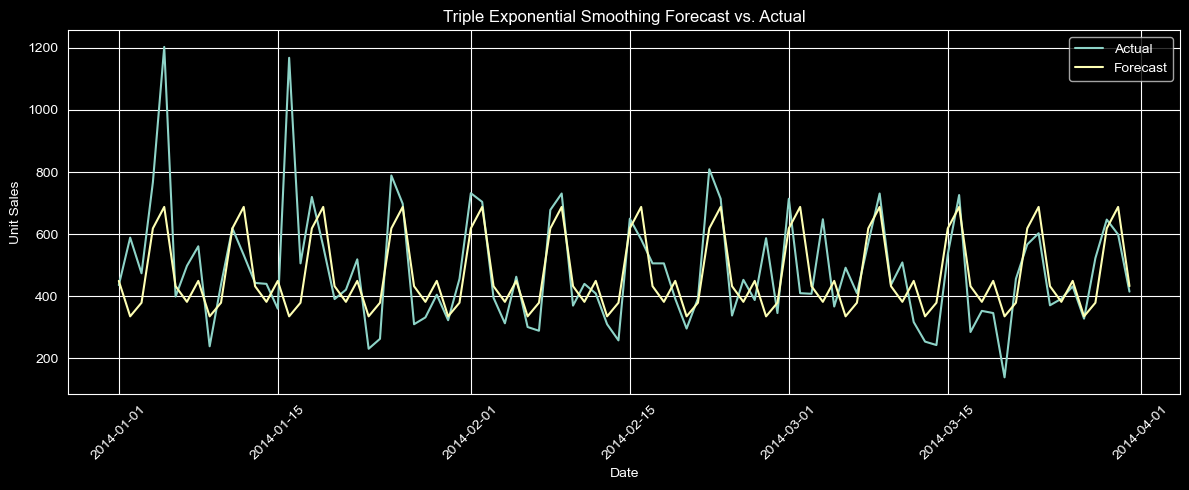

In [68]:
# Forecast-Plot mit fig-Objekt erstellen (nötig für mlflow.log_figure)
test_dates_ES = pd.date_range(start='2014-01-01', periods=len(test_data), freq='D')

fig_ES, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates_ES, actual_ES, label='Actual')
ax.plot(test_dates_ES, predicted_ES, label='Forecast')
ax.legend()
ax.set_title('Triple Exponential Smoothing Forecast vs. Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Unit Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ML Flow
### Starten

In [ ]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db")
mlflow.set_experiment("sales_forecast")

# Jetzt wichtig: mlflow ui mit der DB starten. Im Terminal:
# mlflow ui --backend-store-uri sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db

### Logging

In [69]:
with mlflow.start_run(run_name="Triple_ES"):

    # Qualitative Zusatzinfos
    mlflow.set_tag("forecasting_method", "iterative")
    mlflow.set_tag("model_type", "statistical")

    # Beste Hyperparameter loggen
    mlflow.log_params(best_params_ES)

    # Train/Test-Split Info loggen
    mlflow.log_param("train_size", len(train_data))
    mlflow.log_param("test_size", len(test_data))
    mlflow.log_param("test_start", "2014-01-01")
    mlflow.log_param("test_end", "2014-03-31")

    # Evaluationsmetriken loggen
    mlflow.log_metric("SMAPE", metrics_ES["SMAPE"])
    mlflow.log_metric("RMSE",  metrics_ES["RMSE"])
    mlflow.log_metric("MAD",   metrics_ES["MAD"])
    mlflow.log_metric("rMAD",  metrics_ES["rMAD"])
    mlflow.log_metric("MAPE",  metrics_ES["MAPE"])
    mlflow.log_metric("Bias",  metrics_ES["Bias"])

    # Forecast-Plot als Artefakt speichern
    mlflow.log_figure(fig_ES, "forecast_plot.png")

    # Modell als Artefakt speichern (statsmodels → pickle)
    import pickle
    with open("/tmp/es_model.pkl", "wb") as f:
        pickle.dump(final_model_ES, f)
    mlflow.log_artifact("/tmp/es_model.pkl")

# Prophet
## Format der Time-Series anpassen

In [3]:
from prophet import Prophet
import pandas as pd
from statsmodels.datasets import get_rdataset
import matplotlib.pyplot as plt

/opt/miniconda3/envs/work/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [6]:
# Ich habe in der Zeitreihe das Datum in den Index geschoben
# Dieses Format passt fürs Prophet Modell nicht
# => folgende Anpassung nötig:
train_df = train_data_ts.to_dataframe().reset_index()
train_df.columns = ['ds', 'y']

# Analog für Test (brauche ich später erst...)
test_df = test_data_ts.to_dataframe().reset_index()
test_df.columns = ['ds', 'y']

## Holidays mit reinbringen für Prophet-Vorhersage

In [7]:
path_processed_data = '../Data/Processed/'
time_series_added_features = pd.read_csv(path_processed_data + 'time_series_added_features.csv', parse_dates=['date'])

# Sicherer Merge über Datum
train_df_holiday = train_df.merge(
    time_series_added_features[['date', 'is_holiday']].rename(columns={'date': 'ds'}),
    on='ds',
    how='left'
)

# Prophet akzeptiert keine is_holiday Spalte direkt im Trainingsset, sondern braucht einen separaten DataFrame im Format ds + holiday
holidays_df = train_df_holiday[train_df_holiday['is_holiday'] == 1][['ds']].assign(holiday='public_holiday')

print(train_data_ts.head(4))
print()
print(train_df.head(4))

            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0

shape: (4, 1, 1), freq: D, size: 32.00 B

          ds      y
0 2013-01-02  582.0
1 2013-01-03  310.0
2 2013-01-04  338.0
3 2013-01-05  654.0


## Model building

In [8]:
# Initialize the model
model = Prophet(
    seasonality_mode='additive',
    holidays=holidays_df,
)

# Fit the model
model.fit(train_df)

print("Model fitted successfully!")

10:47:12 - cmdstanpy - INFO - Chain [1] start processing
10:47:12 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully!


## Forecast

In [9]:
# Create future dataframe for predictions
future = model.make_future_dataframe(periods=len(test_data), freq='D')
forecast = model.predict(future)

# Make predictions
forecast = model.predict(future)

print("Forecast columns:")
print(forecast.columns.tolist())

Forecast columns:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'holidays', 'holidays_lower', 'holidays_upper', 'public_holiday', 'public_holiday_lower', 'public_holiday_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']


In [10]:
forecast.head(4)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,public_holiday,public_holiday_lower,public_holiday_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-02,486.747195,319.725833,609.681482,486.747195,486.747195,-20.489358,-20.489358,-20.489358,0.000000,...,0.000000,0.000000,0.000000,-20.489358,-20.489358,-20.489358,0.0,0.0,0.0,466.257837
1,2013-01-03,486.580886,220.583638,508.192679,486.580886,486.580886,-128.711479,-128.711479,-128.711479,0.000000,...,0.000000,0.000000,0.000000,-128.711479,-128.711479,-128.711479,0.0,0.0,0.0,357.869407
2,2013-01-04,486.414576,244.000454,543.771371,486.414576,486.414576,-88.471002,-88.471002,-88.471002,0.000000,...,0.000000,0.000000,0.000000,-88.471002,-88.471002,-88.471002,0.0,0.0,0.0,397.943574
3,2013-01-05,486.248266,529.167499,808.987247,486.248266,486.248266,181.993132,181.993132,181.993132,35.459495,...,35.459495,35.459495,35.459495,146.533637,146.533637,146.533637,0.0,0.0,0.0,668.241399


In [11]:
forecast.tail(4)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,public_holiday,public_holiday_lower,public_holiday_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
450,2014-03-28,469.639077,232.043120,523.415411,468.382775,470.793898,-88.471002,-88.471002,-88.471002,0.0,...,0.0,0.0,0.0,-88.471002,-88.471002,-88.471002,0.0,0.0,0.0,381.168075
451,2014-03-29,469.615598,467.430929,761.298384,468.344651,470.793488,146.533637,146.533637,146.533637,0.0,...,0.0,0.0,0.0,146.533637,146.533637,146.533637,0.0,0.0,0.0,616.149235
452,2014-03-30,469.592119,547.454416,826.235935,468.299963,470.787667,220.288095,220.288095,220.288095,0.0,...,0.0,0.0,0.0,220.288095,220.288095,220.288095,0.0,0.0,0.0,689.880214
453,2014-03-31,469.568639,290.288134,563.322041,468.235373,470.781151,-38.316609,-38.316609,-38.316609,0.0,...,0.0,0.0,0.0,-38.316609,-38.316609,-38.316609,0.0,0.0,0.0,431.252030


## Plotting

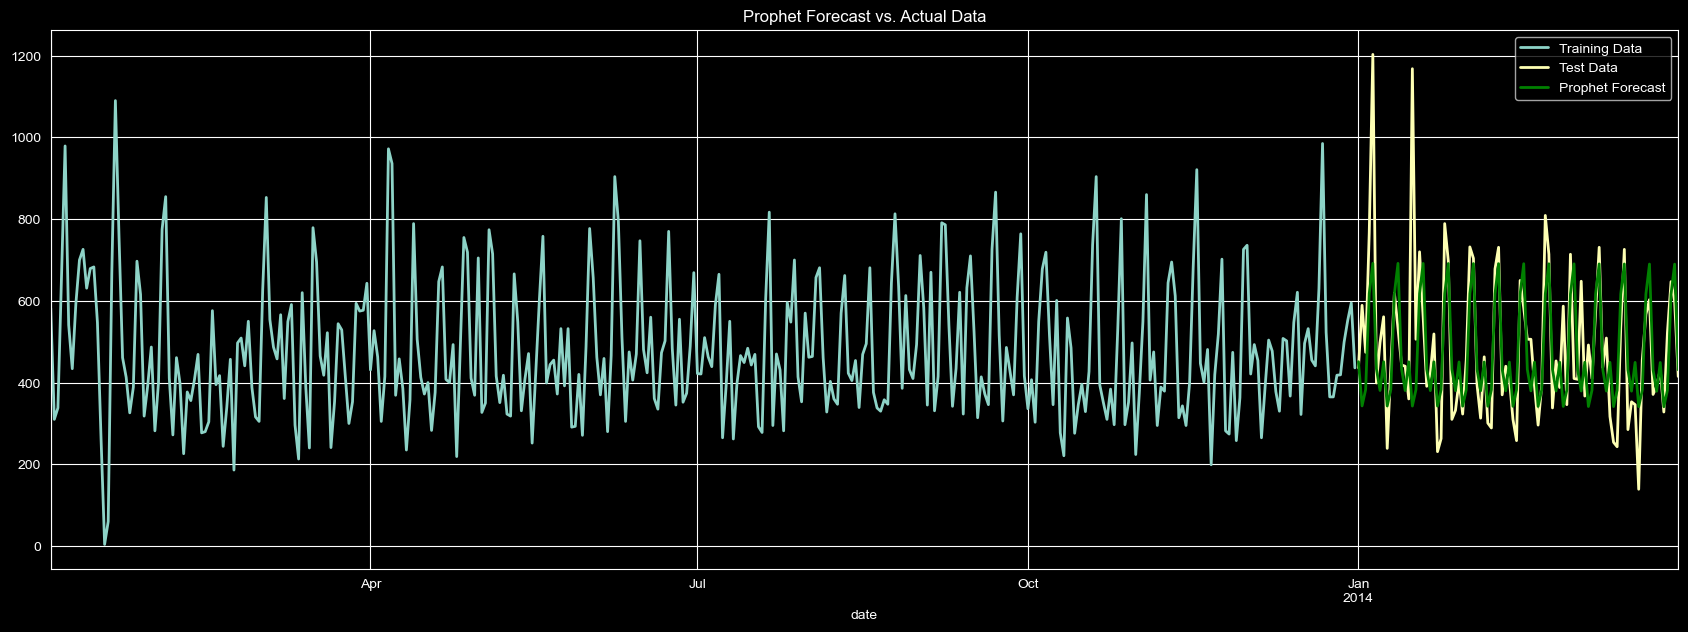

In [12]:
from darts import TimeSeries

# Split: Fitted (2013) vs Forecast (2014)
last_train_date = train_df['ds'].max()
forecast_future = forecast[forecast['ds'] > last_train_date]

# Prophet Forecast → Darts TimeSeries
forecast_ts = TimeSeries.from_dataframe(
    forecast_future[['ds', 'yhat']].rename(columns={'ds': 'date', 'yhat': 'unit_sales'}),
    time_col='date',
    value_cols='unit_sales'
)

# Plot
plt.figure(figsize=(21, 7))
train_data_ts.plot(label='Training Data')
test_data_ts.plot(label='Test Data')
forecast_ts.plot(label='Prophet Forecast', color='green')
plt.title('Prophet Forecast vs. Actual Data')
plt.legend()
plt.show()

## Evaluierung bis hierhin

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Formate anpassen
actual           = test_data_ts.values().flatten()
prophet_forecast_arr = forecast_ts.values().flatten()

mae  = mean_absolute_error(actual, prophet_forecast_arr)
rmse = np.sqrt(mean_squared_error(actual, prophet_forecast_arr))

print(f"Prophet MAE:  {mae:.2f}")
print(f"Prophet RMSE: {rmse:.2f}")
print("Prophet AIC:  nicht verfügbar in Prophet")
print("Prophet BIC:  nicht verfügbar in Prophet")

Prophet MAE:  94.27
Prophet RMSE: 143.31
Prophet AIC:  nicht verfügbar in Prophet
Prophet BIC:  nicht verfügbar in Prophet


## Hyperopt (Hyperparameter Optimization)
### Define the hyperparameter search space

In [15]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

space = {
    # Trend
    'changepoint_prior_scale':   hp.loguniform('changepoint_prior_scale', np.log(0.001), np.log(0.5)),
    #'changepoint_range':         hp.uniform('changepoint_range', 0.7, 0.95),

    # Saisonalität
    'seasonality_prior_scale':   hp.loguniform('seasonality_prior_scale', np.log(0.01), np.log(10)),
    'seasonality_mode':          hp.choice('seasonality_mode', ['additive', 'multiplicative']),

    # Rauschen
    'holidays_prior_scale':      hp.loguniform('holidays_prior_scale', np.log(0.01), np.log(10)),
}

| Parameter | Bedeutung |
|-----------|-----------|
| `changepoint_prior_scale` | Wie flexibel der Trend auf Veränderungen reagiert – hoch = overfitting, niedrig = zu starr |
| `changepoint_range` | Wie viel % der Trainingsdaten für Trendbrüche genutzt werden |
| `seasonality_prior_scale` | Stärke der Saisonalitätskomponente |
| `seasonality_mode` | additiv oder multiplikativ – bei dir wahrscheinlich multiplikativ testen |
| `holidays_prior_scale` | Nur relevant wenn du Feiertage modellierst |

---

-- Warum `loguniform` statt `uniform`?:

`changepoint_prior_scale` variiert sinnvollerweise über mehrere Größenordnungen (0.001 bis 0.5) – `loguniform` sampelt gleichmäßig auf logarithmischer Skala, sonst werden kleine Werte kaum getestet.

### Define Objective Function

In [16]:
def objective(params):
    model = Prophet(
        holidays=holidays_df,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        seasonality_mode=params['seasonality_mode'],
        holidays_prior_scale=params['holidays_prior_scale'],
    )

    model.fit(train_df)

    # Forecast
    future = model.make_future_dataframe(periods=len(test_df))
    forecast = model.predict(future)
    predicted = forecast['yhat'].tail(len(test_df)).values

    # actual lokal definieren
    actual = test_df['y'].values

    errors = actual - predicted
    smape = np.mean(2 * np.abs(errors) / (np.abs(actual) + np.abs(predicted)))
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(actual)
    mape  = np.mean(np.abs(errors) / np.abs(actual)) * 100
    bias  = np.mean(errors)

    return {
        'loss':   smape,
        'status': STATUS_OK,
        'rmse':   rmse,
        'mad':    mad,
        'rmad':   rmad,
        'mape':   mape,
        'bias':   bias,
    }

### Run Optimization

In [17]:
# Initialize trials object to track progress
trials_Prophet = Trials()

# Run optimization
best_Prophet = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=500,
    trials=trials_Prophet
)

print("\nBest parameters found:")
print(best_Prophet)

# Alle Metriken als DataFrame
results_Prophet = pd.DataFrame(trials_Prophet.results)

  0%|          | 0/500 [00:00<?, ?trial/s, best loss=?]

Error processing line 1 of /opt/miniconda3/envs/work/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
10:48:12 - cmdstanpy - INFO - Chain [1] start processing
10:48:12 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 1/500 [00:00<01:30,  5.50trial/s, best loss: 0.19913320600031142]

10:48:12 - cmdstanpy - INFO - Chain [1] start processing
10:48:12 - cmdstanpy - INFO - Chain [1] done processing
10:48:12 - cmdstanpy - INFO - Chain [1] start processing
10:48:12 - cmdstanpy - INFO - Chain [1] done processing


  1%|          | 3/500 [00:00<00:58,  8.47trial/s, best loss: 0.19913320600031142]

...

 99%|█████████▉| 496/500 [00:48<00:00, 10.44trial/s, best loss: 0.19610163896835328]

10:49:00 - cmdstanpy - INFO - Chain [1] start processing
10:49:00 - cmdstanpy - INFO - Chain [1] done processing
10:49:00 - cmdstanpy - INFO - Chain [1] start processing
10:49:00 - cmdstanpy - INFO - Chain [1] done processing


100%|█████████▉| 498/500 [00:48<00:00, 10.41trial/s, best loss: 0.19610163896835328]

10:49:01 - cmdstanpy - INFO - Chain [1] start processing
10:49:01 - cmdstanpy - INFO - Chain [1] done processing
10:49:01 - cmdstanpy - INFO - Chain [1] start processing
10:49:01 - cmdstanpy - INFO - Chain [1] done processing


100%|██████████| 500/500 [00:48<00:00, 10.24trial/s, best loss: 0.19610163896835328]

Best parameters found:
{'changepoint_prior_scale': np.float64(0.2857118918951094), 'holidays_prior_scale': np.float64(0.014640234441796055), 'seasonality_mode': np.int64(0), 'seasonality_prior_scale': np.float64(8.504186297998663)}


In [100]:
results_Prophet.sort_values('loss').head(1)

,loss,status,rmse,mad,rmad,mape,bias
140,0.195327,ok,145.268165,92.746979,0.191121,19.459148,26.480685


## Finales Modell mit besten Hyperparametern
### Beste Hyperparameter extrahieren

In [23]:
import pandas as pd
pd.DataFrame([trials_Prophet.best_trial['misc']['vals']])

,changepoint_prior_scale,holidays_prior_scale,seasonality_mode,seasonality_prior_scale
0,[0.2857118918951094],[0.014640234441796055],[0],[8.504186297998663]


In [18]:
# Besten Trial finden
best_trial_Prophet = trials_Prophet.best_trial['misc']['vals']

# Parameter extrahieren (hp.choice → Index → Wert mappen)
best_params_Prophet = {
    'changepoint_prior_scale':  best_trial_Prophet['changepoint_prior_scale'][0],
    'seasonality_prior_scale':  best_trial_Prophet['seasonality_prior_scale'][0],
    'seasonality_mode':         ['additive', 'multiplicative'][int(best_trial_Prophet['seasonality_mode'][0])],
    'holidays_prior_scale':     best_trial_Prophet['holidays_prior_scale'][0],
}

print(best_params_Prophet)

{'changepoint_prior_scale': np.float64(0.2857118918951094), 'seasonality_prior_scale': np.float64(8.504186297998663), 'seasonality_mode': 'additive', 'holidays_prior_scale': np.float64(0.014640234441796055)}


## Trainieren

In [24]:
# Finales Prophet-Modell mit besten Parametern trainieren
final_model_Prophet = Prophet(
    holidays=holidays_df,
    changepoint_prior_scale=best_params_Prophet['changepoint_prior_scale'],
    seasonality_prior_scale=best_params_Prophet['seasonality_prior_scale'],
    seasonality_mode=best_params_Prophet['seasonality_mode'],
    holidays_prior_scale=best_params_Prophet['holidays_prior_scale'],
)

final_model_Prophet.fit(train_df)

11:02:44 - cmdstanpy - INFO - Chain [1] start processing
11:02:44 - cmdstanpy - INFO - Chain [1] done processing


## Forecast

In [25]:
# Forecast für den Testzeitraum (90 Tage, iteratives Forecasting)
future = final_model_Prophet.make_future_dataframe(periods=len(test_df), freq='D')
prophet_forecast_final = final_model_Prophet.predict(future)

# Nur die Testperiode extrahieren
predicted_Prophet = prophet_forecast_final['yhat'].tail(len(test_df)).values

## Evaluation

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

def forecast_metrics(y_true, y_pred):
    errors = y_true - y_pred
    smape = np.mean(2 * np.abs(errors) / (np.abs(y_true) + np.abs(y_pred)))
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mad   = np.mean(np.abs(errors))
    rmad  = mad / np.mean(y_true)
    mape  = np.mean(np.abs(errors) / np.abs(y_true)) * 100
    bias  = np.mean(errors)

    return {
        'SMAPE': smape,
        'RMSE':  rmse,
        'MAD':   mad,
        'rMAD':  rmad,
        'MAPE':  mape,
        'Bias':  bias,
    }

# Evaluation
actual_Prophet = test_df['y'].values

metrics_Prophet = forecast_metrics(actual_Prophet, predicted_Prophet)
for k, v in metrics_Prophet.items():
    print(f"{k}: {v:,.2f}")

SMAPE: 0.20
RMSE: 143.95
MAD: 93.22
rMAD: 0.19
MAPE: 19.73
Bias: 25.55


## Plotting

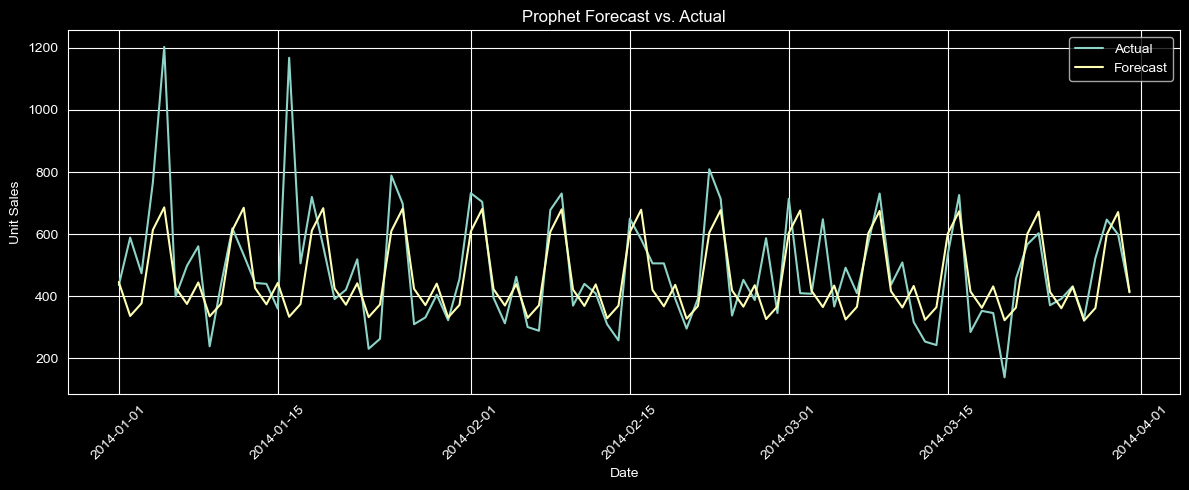

In [28]:
# Forecast-Plot mit fig-Objekt erstellen (nötig für mlflow.log_figure)
test_dates_Prophet = pd.date_range(start='2014-01-01', periods=len(test_df), freq='D')

fig_Prophet, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates_Prophet, actual_Prophet, label='Actual')
ax.plot(test_dates_Prophet, predicted_Prophet, label='Forecast')
ax.legend()
ax.set_title('Prophet Forecast vs. Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Unit Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ML FLow
### Initialisierung

In [32]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db")
mlflow.set_experiment("sales_forecast")

# Jetzt wichtig: mlflow ui mit der DB starten.
# mlflow ui --backend-store-uri sqlite:////Users/matthiasmuschket/PycharmProjects/260414_Time_Series_Masterschool/mlflow.db

Error processing line 1 of /opt/miniconda3/envs/work/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
Error processing line 1 of /opt/miniconda3/envs/work/lib/python3.11/site-packages/distutils-precedence.pth:

Error processing line 1 of /opt/miniconda3/envs/work/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignore

### Logging

In [33]:
with mlflow.start_run(run_name="Prophet"):

    # Qualitative Zusatzinfos
    mlflow.set_tag("forecasting_method", "iterative")
    mlflow.set_tag("model_type", "statistical")

    # Beste Hyperparameter loggen
    mlflow.log_params(best_params_Prophet)

    # Train/Test-Split Info loggen
    mlflow.log_param("train_size", len(train_df))
    mlflow.log_param("test_size", len(test_df))
    mlflow.log_param("test_start", "2014-01-01")
    mlflow.log_param("test_end", "2014-03-31")

    # Evaluationsmetriken loggen
    mlflow.log_metric("SMAPE", metrics_Prophet["SMAPE"])
    mlflow.log_metric("RMSE",  metrics_Prophet["RMSE"])
    mlflow.log_metric("MAD",   metrics_Prophet["MAD"])
    mlflow.log_metric("rMAD",  metrics_Prophet["rMAD"])
    mlflow.log_metric("MAPE",  metrics_Prophet["MAPE"])
    mlflow.log_metric("Bias",  metrics_Prophet["Bias"])

    # Forecast-Plot als Artefakt speichern
    mlflow.log_figure(fig_Prophet, "forecast_plot.png")

    # Modell als Artefakt speichern (Prophet → pickle)
    import pickle
    with open("/tmp/prophet_model.pkl", "wb") as f:
        pickle.dump(final_model_Prophet, f)
    mlflow.log_artifact("/tmp/prophet_model.pkl")